In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from EMDPM.visualization import *
from EMDPM.utils import solve_system
from sklearn.decomposition import PCA
from scipy.stats import chi2_contingency, kendalltau
import os
import glob

# Find all grid search result files
result_dir = "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/qsub_results/ppmi_gridsearch_refined"
pattern = os.path.join(result_dir, "PPMI_subtyping_grid_*.npz")
paths = sorted(glob.glob(pattern))
print(f"Found {len(paths)} result files")

def load_results(paths):
    results = {}
    for path in paths:
        key = os.path.splitext(os.path.basename(path))[0]
        try:
            data = np.load(path, allow_pickle=True)
            results[key] = data
        except Exception as e:
            print(f"Error loading {key}: {e}")
    return results

results = load_results(paths)
print(f"\nTotal loaded: {len(results)} results")


Found 63 result files

Total loaded: 63 results


In [2]:
# Extract summary statistics for all models
n_biomarkers = 68
summary = []

for cand, data in results.items():
    try:
        # Extract final values
        final_lse = data["lse_history"][-1] if "lse_history" in data.files else np.nan
        
        # Extract cluster parameters
        if "cluster_f" in data.files:
            cluster_f = data["cluster_f"]
            n_subtypes = cluster_f.shape[0]
        else:
            cluster_f = None
            n_subtypes = 0
        
        final_scalar_K = data["final_scalar_K"] if "final_scalar_K" in data.files else np.nan
        final_s = data["final_s"] if "final_s" in data.files else np.nan
        
        # Extract candidate number
        candidate_num = data["candidate"] if "candidate" in data.files else int(cand.split("_")[-1])
        
        # Extract assignment statistics
        if "final_assignments" in data.files:
            assignments = data["final_assignments"]
            subtype_counts = np.bincount(assignments, minlength=n_subtypes) if n_subtypes > 0 else []
        else:
            subtype_counts = []
        
        summary.append({
            "candidate": candidate_num,
            "key": cand,
            "final_lse": final_lse,
            "n_subtypes": n_subtypes,
            "scalar_K": final_scalar_K,
            "mean_s": np.mean(final_s) if isinstance(final_s, np.ndarray) else final_s,
            "subtype0_count": subtype_counts[0] if len(subtype_counts) > 0 else np.nan,
            "subtype1_count": subtype_counts[1] if len(subtype_counts) > 1 else np.nan,
        })
    except Exception as e:
        print(f"Error processing {cand}: {e}")
        continue

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values("final_lse").reset_index(drop=True)
print("\n=== Summary Statistics (sorted by LSE) ===")
print(summary_df[["candidate", "final_lse", "n_subtypes", "scalar_K", "mean_s"]].head(10))

# Find best model (lowest LSE)
best_row = summary_df.iloc[0]
best_key = best_row["key"]
best_data = results[best_key]

print(f"\n=== Best Model (Lowest LSE) ===")
print(f"Key: {best_key}")
print(f"Final LSE: {best_row['final_lse']:.6f}")
if "lambda_f" in best_data.files:
    print(f"\nParameters:")
    print(f"  lambda_f: {best_data['lambda_f']}")
    print(f"  lambda_cog: {best_data['lambda_cog']}")
    print(f"  lambda_scalar: {best_data['lambda_scalar']}")
    print(f"  lambda_jsd: {best_data['lambda_jsd']}")
    print(f"  lambda_beta: {best_data['lambda_beta']}")



=== Summary Statistics (sorted by LSE) ===
  candidate   final_lse  n_subtypes             scalar_K    mean_s
0        10  754.895041           2  0.09841321680270262  0.490821
1         8  759.942630           2  0.10902558539839524  0.490320
2        22  760.916453           2  0.12402283061591705  0.489652
3        20  762.383032           2  0.11832394636489571  0.489912
4         6  762.788578           2  0.12127377143622402  0.489521
5        35  767.946686           2  0.12847301808844552  0.487680
6        34  773.233231           2  0.17136618939836817  0.486997
7        23  775.285871           2  0.22080869962127594  0.487107
8         7  777.393806           2  0.18762416914566163  0.485361
9        11  777.963925           2  0.17189923040793614  0.486550

=== Best Model (Lowest LSE) ===
Key: PPMI_subtyping_grid_010_lambda_f0p500_lambda_cog0p200_lambda_scalar0p800_lambda_jsd0p200_lambda_beta0p100
Final LSE: 754.895041

Parameters:
  lambda_f: 0.5
  lambda_cog: 0.2
  lamb

In [3]:
# Load PPMI data for analysis
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv")

## remove non-longitudinal observations
print("original size:", df.shape)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

subj_counts = df['subj_id'].value_counts()
longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs

## connectivity matrix to numpy
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)

# normalization
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

t_max = 40
t_span = np.linspace(0, t_max, int(t_max/0.01))

biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

# Extract arrays for analysis
ids_all = df["subj_id"].to_numpy()
dt_all = df["time"].to_numpy()/12  # convert to years
nhy_all = df["NHY"].to_numpy()
cog_all = df[["MCATOT","TD_score","PIGD_score"]].to_numpy()
df["NSD_STAGE"] = df["NSD_STAGE"].replace({"Not NSD": 0, "2b": 2})
df["NSD_STAGE"] = pd.to_numeric(df["NSD_STAGE"], errors='coerce')
nsd = df["NSD_STAGE"].to_numpy()

print(f"Loaded data: {X_obs.shape}, K: {K.shape}, biomarkers: {len(biomarker_names)}")
print(f"Patients: {len(np.unique(ids_all))}, Observations: {len(ids_all)}")


original size: (880, 250)
Loaded data: (504, 68), K: (68, 68), biomarkers: 68
Patients: 146, Observations: 504


In [4]:
# Extract best model assignments and betas
train_ids = best_data["train_ids"]
val_ids = best_data["val_ids"] if "val_ids" in best_data.files else []
beta_train = best_data["beta_history"][:, -1]
beta_val = best_data["beta_val"] if "beta_val" in best_data.files else []

# Combine train and val
all_ids_list = list(train_ids) + list(val_ids)
all_betas_list = list(beta_train) + list(beta_val)
pid_to_beta = {pid: beta for pid, beta in zip(all_ids_list, all_betas_list)}

train_assignments = best_data["train_assignments"]
val_assignments = best_data["val_assignments"] if "val_assignments" in best_data.files else []
all_assignments_list = list(train_assignments) + list(val_assignments)
pid_to_assignment = {pid: assign for pid, assign in zip(all_ids_list, all_assignments_list)}

# Get beta values and assignments aligned with ids_all
beta_all = np.array([pid_to_beta.get(pid, np.nan) for pid in ids_all])
assignment_all = np.array([pid_to_assignment.get(pid, -1) for pid in ids_all])

# Filter to valid patients
valid_mask = np.array([pid in pid_to_beta for pid in ids_all])
ids_valid = ids_all[valid_mask]
beta_valid = beta_all[valid_mask]
assignment_valid = assignment_all[valid_mask]
nhy_valid = nhy_all[valid_mask]
nsd_valid = nsd[valid_mask]
cog_valid = cog_all[valid_mask]

print(f"Valid patients: {len(np.unique(ids_valid))}")
print(f"Subtype 0: {np.sum(assignment_valid == 0)} patients")
print(f"Subtype 1: {np.sum(assignment_valid == 1)} patients")


Valid patients: 146
Subtype 0: 318 patients
Subtype 1: 186 patients



Subtype 0:
  Intercept (cog_b): 3.7326
  MCATOT coefficient: 0.2178
  TD_score coefficient: -0.1484
  PIGD_score coefficient: 0.2448
s_ij = 3.7326 +0.2178 * MCATOT +-0.1484 * TD +0.2448 * PIGD

Subtype 1:
  Intercept (cog_b): 33.6796
  MCATOT coefficient: -0.1064
  TD_score coefficient: -0.1700
  PIGD_score coefficient: 0.3448
s_ij = 33.6796 +-0.1064 * MCATOT +-0.1700 * TD +0.3448 * PIGD


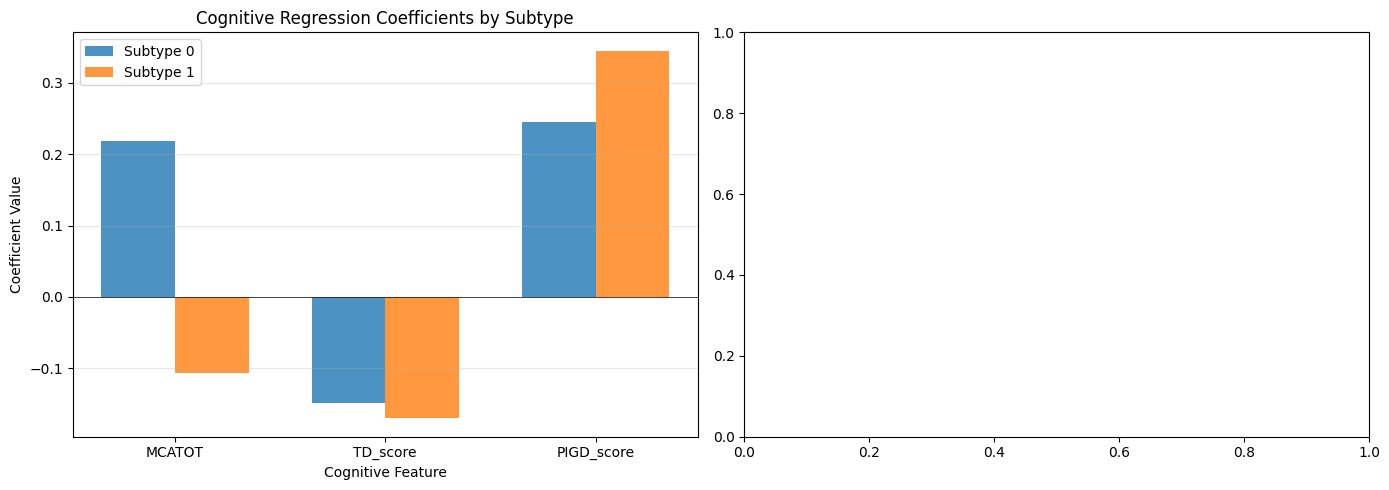

In [5]:
# Cognitive Parameter Comparison
cluster_cog_a = best_data["cluster_cog_a"]  # (n_subtypes, n_cog_features)
cluster_cog_b = best_data["cluster_cog_b"]  # (n_subtypes,)

cog_feature_names = ['MCATOT', 'TD_score', 'PIGD_score']

for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype}:")
    print(f"  Intercept (cog_b): {cluster_cog_b[subtype]:.4f}")
    for i, name in enumerate(cog_feature_names):
        print(f"  {name} coefficient: {cluster_cog_a[subtype, i]:.4f}")

    print(f"s_ij = {cluster_cog_b[subtype]:.4f} +\
{cluster_cog_a[subtype, 0]:.4f} * MCATOT +\
{cluster_cog_a[subtype, 1]:.4f} * TD +\
{cluster_cog_a[subtype, 2]:.4f} * PIGD")


# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Coefficients comparison
x = np.arange(len(cog_feature_names))
width = 0.35
axes[0].bar(x - width/2, cluster_cog_a[0], width, label='Subtype 0', alpha=0.8)
axes[0].bar(x + width/2, cluster_cog_a[1], width, label='Subtype 1', alpha=0.8)
axes[0].set_xlabel('Cognitive Feature')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Cognitive Regression Coefficients by Subtype')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cog_feature_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

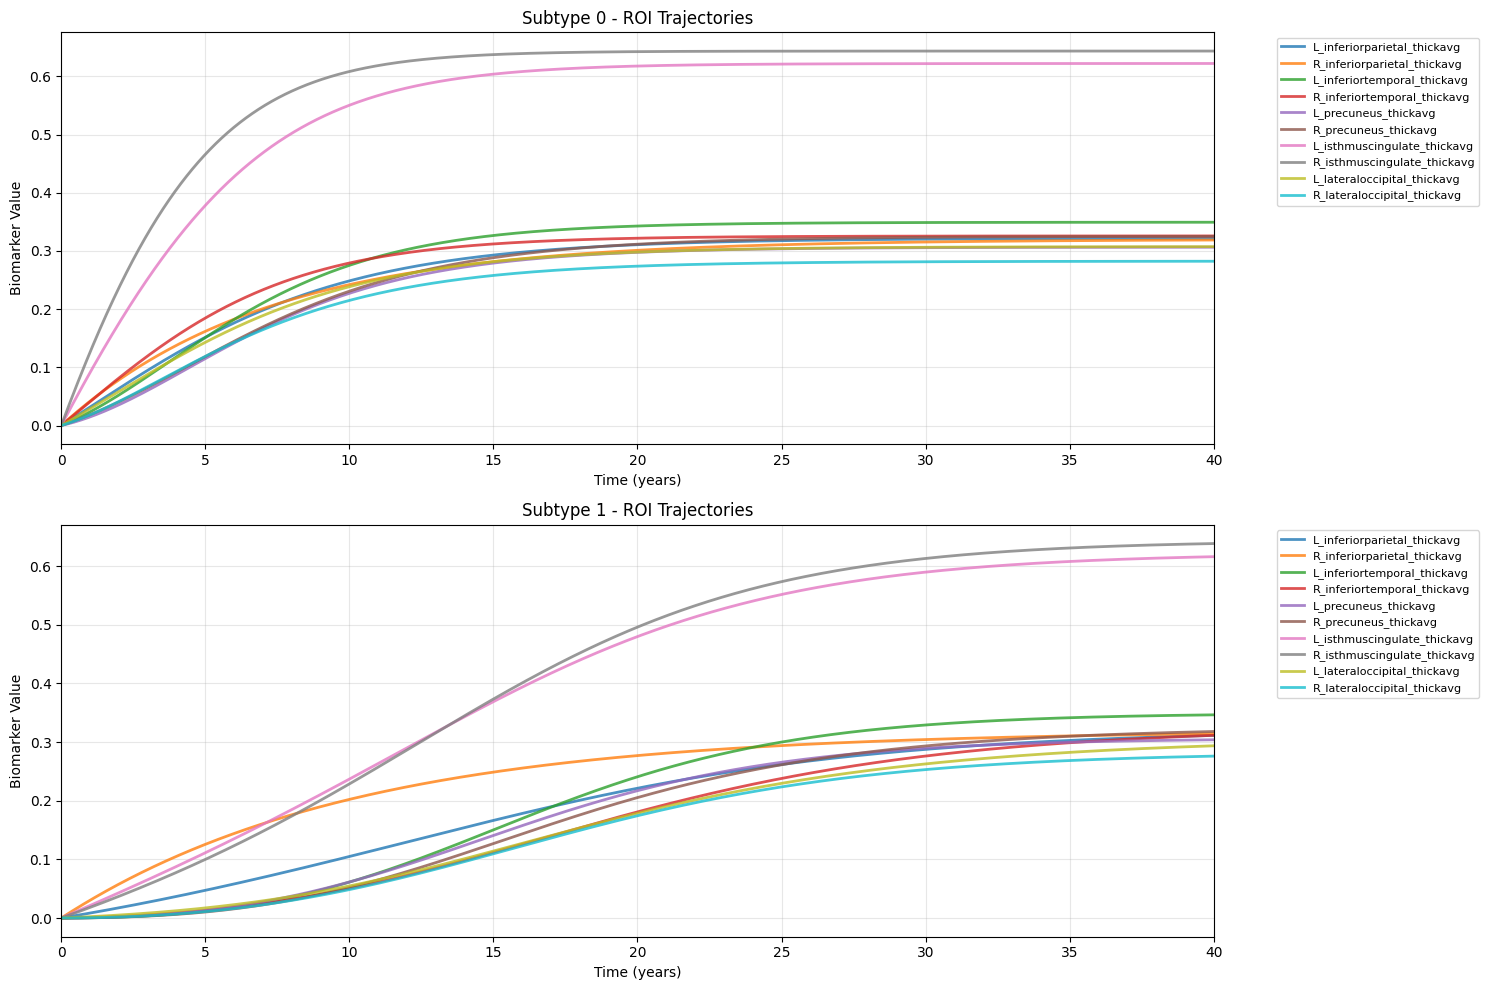

In [6]:
# ROI Subplots: 10 ROI trajectories for each subtype
ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

final_scalar_K = best_data["final_scalar_K"]
final_s = best_data["final_s"]

# Plot trajectories for each subtype
fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5*n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K) * final_s[:, None]
    
    ax = axes[subtype]
    for i, roi_idx in enumerate(ROI):
        ax.plot(t_span, Xtraj_subtype[roi_idx], label=ROI_names[i], linewidth=2, alpha=0.8)
    
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value")
    ax.set_title(f"Subtype {subtype} - ROI Trajectories")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

plt.tight_layout()
plt.show()



CONTINGENCY TABLE: Discovered Subtypes vs Clinical Subgroups ===
Clinical Subgroup   Non-Sporadic PD  Sporadic PD
Discovered Subtype                              
0                                 7           84
1                                 5           50

Chi-square test:
  χ² = 0.0000
  p-value = 1.0000
  df = 1


<Figure size 1000x600 with 0 Axes>

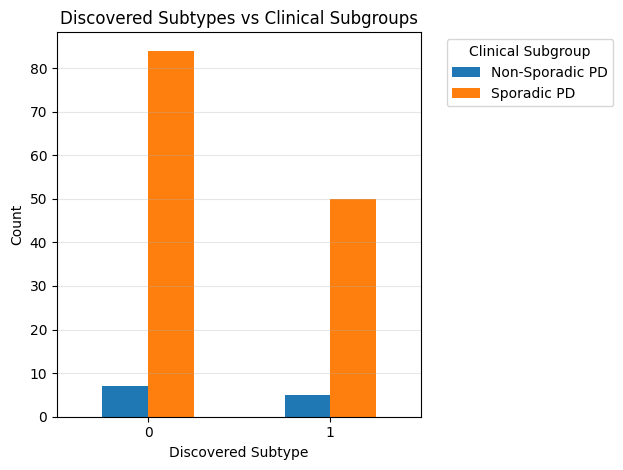

In [7]:
# Clinical Subgroup Comparison: Sporadic PD vs Non-Sporadic PD
unique_pids = np.unique(ids_valid)
pid_to_subgroup = {}
for pid in unique_pids:
    mask = df['subj_id'] == pid
    if mask.sum() > 0:
        subgroups = df.loc[mask, 'subgroup'].dropna().unique()
        if len(subgroups) > 0:
            pid_to_subgroup[pid] = subgroups[0] if len(subgroups) == 1 else df.loc[mask, 'subgroup'].mode()[0]

# Map to our assignments
subgroup_per_patient = np.array([pid_to_subgroup.get(pid, 'Unknown') for pid in unique_pids])
assignment_per_patient = np.array([pid_to_assignment.get(pid, -1) for pid in unique_pids])

# Create binary classification: Sporadic PD vs Non-Sporadic PD
sporadic_mask = np.array([sg == 'Sporadic PD' if isinstance(sg, str) else False for sg in subgroup_per_patient])
clinical_subgroup = np.where(sporadic_mask, 'Sporadic PD', 'Non-Sporadic PD')

# Create contingency table
contingency = pd.crosstab(
    pd.Series(assignment_per_patient, name='Discovered Subtype'),
    pd.Series(clinical_subgroup, name='Clinical Subgroup')
)
print("\nCONTINGENCY TABLE: Discovered Subtypes vs Clinical Subgroups ===")
print(contingency)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square test:")
print(f"  χ² = {chi2:.4f}")
print(f"  p-value = {p_value:.4f}")
print(f"  df = {dof}")

# Plot
plt.figure(figsize=(10, 6))
contingency.plot(kind='bar', stacked=False)
plt.title('Discovered Subtypes vs Clinical Subgroups')
plt.xlabel('Discovered Subtype')
plt.ylabel('Count')
plt.legend(title='Clinical Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



Subtype 0 Beta Statistics:
  Mean: 7.9097
  Median: 7.8737
  Std: 0.9617

Subtype 1 Beta Statistics:
  Mean: 29.1808
  Median: 29.0454
  Std: 1.2222


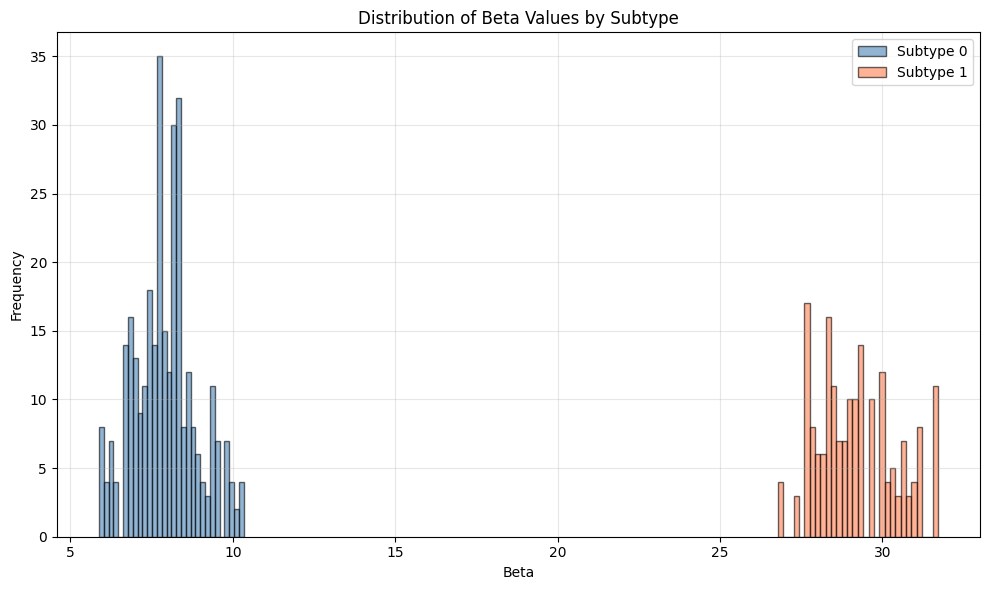

In [8]:
# Beta distributions by subtype
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral']
for subtype in range(n_subtypes):
    beta_subtype = beta_valid[assignment_valid == subtype]
    plt.hist(beta_subtype, bins=30, alpha=0.6, label=f'Subtype {subtype}', 
             color=colors[subtype], edgecolor='black')
    print(f"\nSubtype {subtype} Beta Statistics:")
    print(f"  Mean: {np.mean(beta_subtype):.4f}")
    print(f"  Median: {np.median(beta_subtype):.4f}")
    print(f"  Std: {np.std(beta_subtype):.4f}")

plt.xlabel("Beta")
plt.ylabel("Frequency")
plt.title("Distribution of Beta Values by Subtype")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


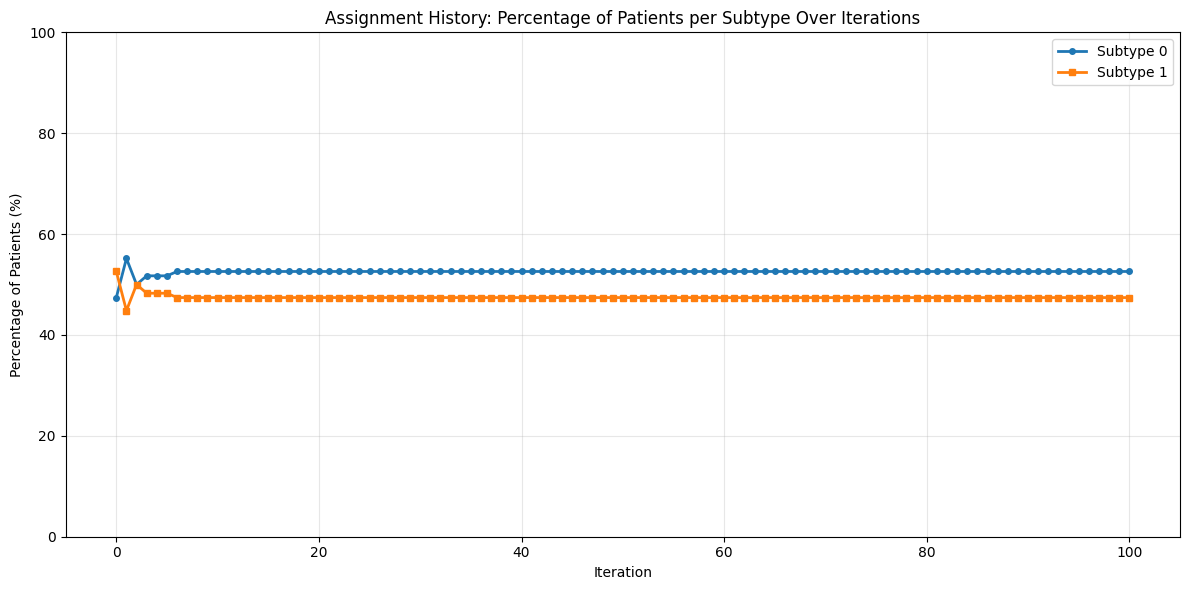


Assignment History Summary:
  Initial - Subtype 0: 47.4%, Subtype 1: 52.6%
  Final   - Subtype 0: 52.6%, Subtype 1: 47.4%
  Change  - Subtype 0: 5.2%, Subtype 1: -5.2%


In [9]:
# Plot assignment history over iterations
if "assignment_history" in best_data.files:
    assignment_history = best_data["assignment_history"]  # (n_patients, n_iterations+1)
    n_iterations = assignment_history.shape[1] - 1
    
    # Calculate percentage of subtype 0 and 1 for each iteration
    pct_subtype0 = []
    pct_subtype1 = []
    
    for iter_idx in range(n_iterations + 1):
        assignments_iter = assignment_history[:, iter_idx]
        n_patients = len(assignments_iter)
        n_subtype0 = np.sum(assignments_iter == 0)
        n_subtype1 = np.sum(assignments_iter == 1)
        
        pct_subtype0.append(100 * n_subtype0 / n_patients)
        pct_subtype1.append(100 * n_subtype1 / n_patients)
    
    # Plot
    plt.figure(figsize=(12, 6))
    iterations = np.arange(n_iterations + 1)
    plt.plot(iterations, pct_subtype0, label='Subtype 0', linewidth=2, marker='o', markersize=4)
    plt.plot(iterations, pct_subtype1, label='Subtype 1', linewidth=2, marker='s', markersize=4)
    plt.xlabel('Iteration')
    plt.ylabel('Percentage of Patients (%)')
    plt.title('Assignment History: Percentage of Patients per Subtype Over Iterations')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()
    
    print(f"\nAssignment History Summary:")
    print(f"  Initial - Subtype 0: {pct_subtype0[0]:.1f}%, Subtype 1: {pct_subtype1[0]:.1f}%")
    print(f"  Final   - Subtype 0: {pct_subtype0[-1]:.1f}%, Subtype 1: {pct_subtype1[-1]:.1f}%")
    print(f"  Change  - Subtype 0: {pct_subtype0[-1] - pct_subtype0[0]:.1f}%, Subtype 1: {pct_subtype1[-1] - pct_subtype1[0]:.1f}%")
else:
    print("Assignment history not available in best_data")


Forcing term comparison across 68 brain regions:
  Subtype 0 - Mean: 0.1719, Std: 0.1018, Range: [0.0000, 0.4784]
  Subtype 1 - Mean: 0.0545, Std: 0.0389, Range: [0.0000, 0.1527]
  Difference - Mean: 0.1174, Std: 0.0890


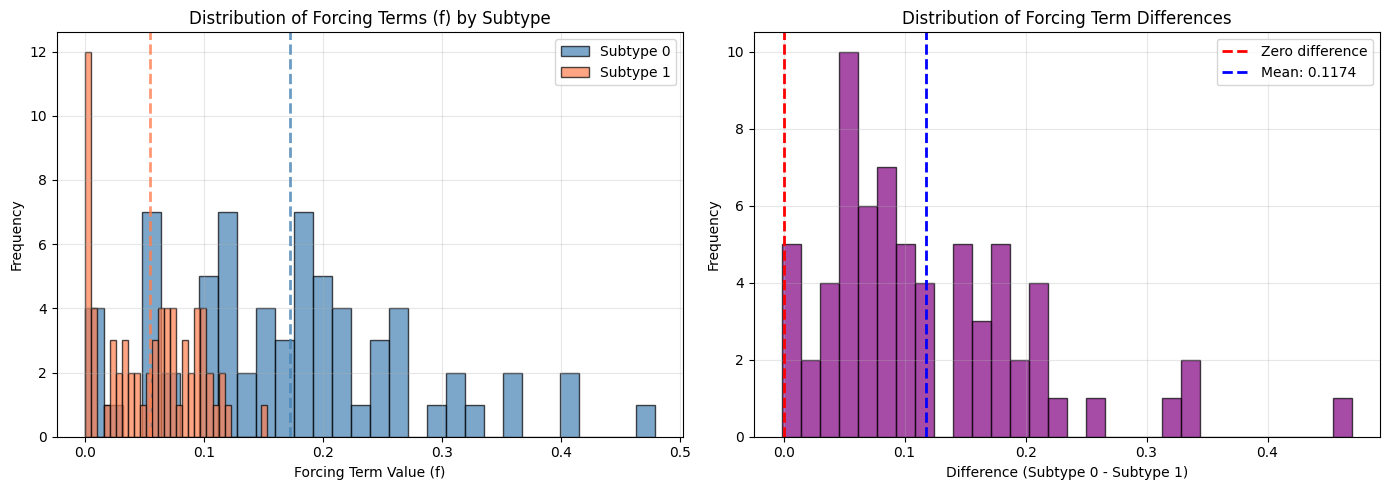

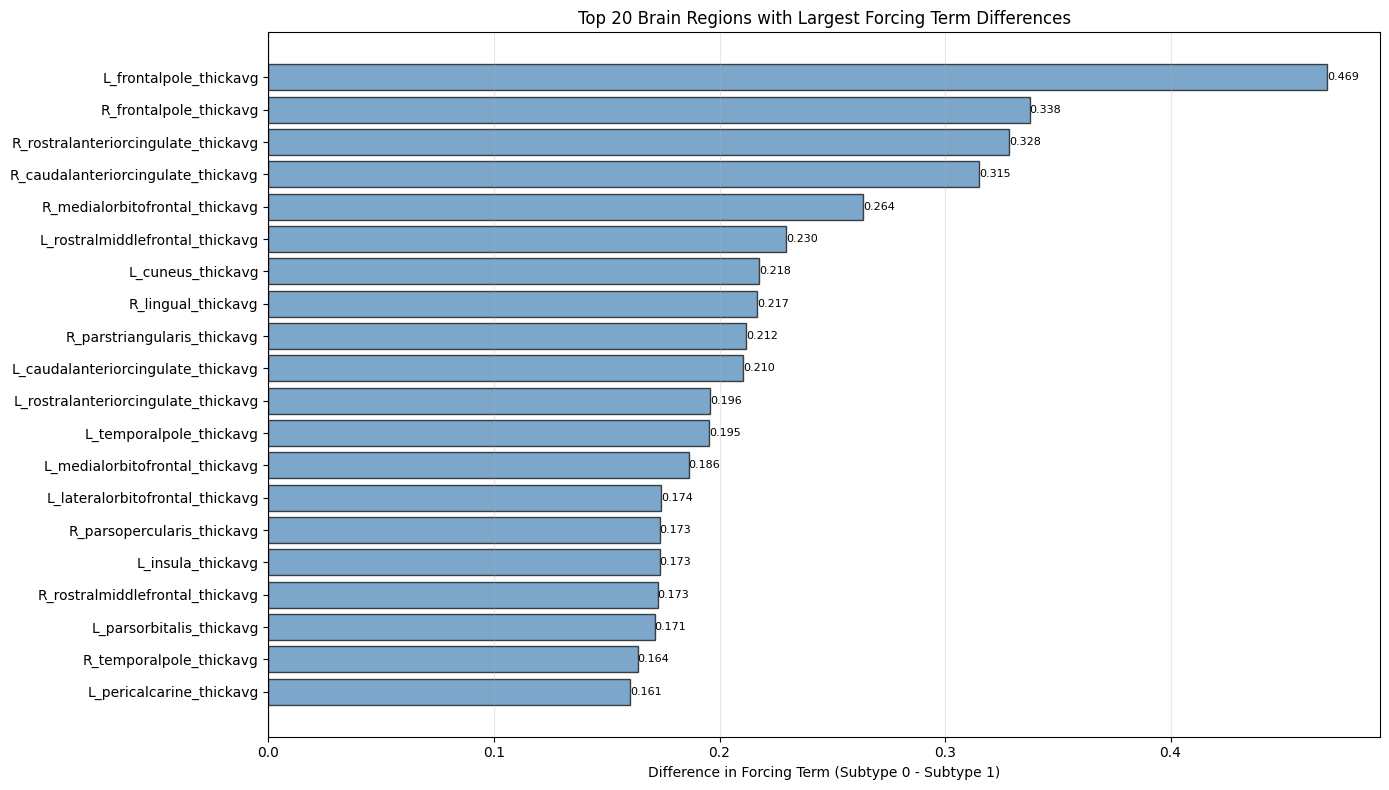


Top 20 regions with largest differences:
  1. L_frontalpole_thickavg: 0.4694 (Subtype 0: 0.4784, Subtype 1: 0.0090)
  2. R_frontalpole_thickavg: 0.3375 (Subtype 0: 0.4103, Subtype 1: 0.0728)
  3. R_rostralanteriorcingulate_thickavg: 0.3283 (Subtype 0: 0.3549, Subtype 1: 0.0266)
  4. R_caudalanteriorcingulate_thickavg: 0.3153 (Subtype 0: 0.3998, Subtype 1: 0.0845)
  5. R_medialorbitofrontal_thickavg: 0.2636 (Subtype 0: 0.3512, Subtype 1: 0.0877)
  6. L_rostralmiddlefrontal_thickavg: 0.2296 (Subtype 0: 0.3157, Subtype 1: 0.0861)
  7. L_cuneus_thickavg: 0.2177 (Subtype 0: 0.3318, Subtype 1: 0.1141)
  8. R_lingual_thickavg: 0.2168 (Subtype 0: 0.2398, Subtype 1: 0.0230)
  9. R_parstriangularis_thickavg: 0.2118 (Subtype 0: 0.2693, Subtype 1: 0.0576)
  10. L_caudalanteriorcingulate_thickavg: 0.2103 (Subtype 0: 0.3078, Subtype 1: 0.0975)
  11. L_rostralanteriorcingulate_thickavg: 0.1959 (Subtype 0: 0.1978, Subtype 1: 0.0019)
  12. L_temporalpole_thickavg: 0.1955 (Subtype 0: 0.2917, Subtype 1:

In [10]:
# Compare forcing terms (f) between subtypes for all 68 brain regions
cluster_f = best_data["cluster_f"]  # (n_subtypes, n_biomarkers)
n_subtypes = cluster_f.shape[0]
n_biomarkers = cluster_f.shape[1]

f_subtype0 = cluster_f[0]  # (68,)
f_subtype1 = cluster_f[1]  # (68,)

# Get biomarker names
biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]

print(f"Forcing term comparison across {n_biomarkers} brain regions:")
print(f"  Subtype 0 - Mean: {np.mean(f_subtype0):.4f}, Std: {np.std(f_subtype0):.4f}, Range: [{np.min(f_subtype0):.4f}, {np.max(f_subtype0):.4f}]")
print(f"  Subtype 1 - Mean: {np.mean(f_subtype1):.4f}, Std: {np.std(f_subtype1):.4f}, Range: [{np.min(f_subtype1):.4f}, {np.max(f_subtype1):.4f}]")
print(f"  Difference - Mean: {np.mean(f_subtype0 - f_subtype1):.4f}, Std: {np.std(f_subtype0 - f_subtype1):.4f}")

# Histogram of both forcing terms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(f_subtype0, bins=30, alpha=0.7, color='steelblue', edgecolor='black', label='Subtype 0')
axes[0].hist(f_subtype1, bins=30, alpha=0.7, color='coral', edgecolor='black', label='Subtype 1')
axes[0].axvline(np.mean(f_subtype0), color='steelblue', linestyle='--', linewidth=2, alpha=0.8)
axes[0].axvline(np.mean(f_subtype1), color='coral', linestyle='--', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Forcing Term Value (f)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Forcing Terms (f) by Subtype')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of differences
f_diff = f_subtype0 - f_subtype1
axes[1].hist(f_diff, bins=30, alpha=0.7, color='purple', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero difference')
axes[1].axvline(np.mean(f_diff), color='blue', linestyle='--', linewidth=2, label=f'Mean: {np.mean(f_diff):.4f}')
axes[1].set_xlabel('Difference (Subtype 0 - Subtype 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Forcing Term Differences')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Bar chart showing biggest differences
f_diff_abs = np.abs(f_diff)
top_n = 20  # Show top 20 biggest differences
top_indices = np.argsort(f_diff_abs)[-top_n:][::-1]

fig, ax = plt.subplots(figsize=(14, 8))
x_pos = np.arange(len(top_indices))
colors_bar = ['steelblue' if f_diff[idx] > 0 else 'coral' for idx in top_indices]
bars = ax.barh(x_pos, f_diff[top_indices], color=colors_bar, alpha=0.7, edgecolor='black')

ax.set_yticks(x_pos)
ax.set_yticklabels([biomarker_names[idx] for idx in top_indices])
ax.set_xlabel('Difference in Forcing Term (Subtype 0 - Subtype 1)')
ax.set_title(f'Top {top_n} Brain Regions with Largest Forcing Term Differences')
ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()  # Show largest differences at top

# Add value labels on bars
for i, (idx, bar) in enumerate(zip(top_indices, bars)):
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, 
            f'{width:.3f}', ha='left' if width > 0 else 'right', 
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nTop {top_n} regions with largest differences:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}. {biomarker_names[idx]}: {f_diff[idx]:.4f} (Subtype 0: {f_subtype0[idx]:.4f}, Subtype 1: {f_subtype1[idx]:.4f})")


In [11]:
top10_df = summary_df.head(10)
display_cols = ["candidate", "final_lse", "scalar_K", "mean_s", "subtype0_count", "subtype1_count"]
if all(col in top10_df.columns for col in display_cols):
    print(top10_df[display_cols].to_string(index=False))
else:
    print(top10_df)


candidate  final_lse            scalar_K   mean_s  subtype0_count  subtype1_count
       10 754.895041 0.09841321680270262 0.490821              61              55
        8 759.942630 0.10902558539839524 0.490320              61              55
       22 760.916453 0.12402283061591705 0.489652              61              55
       20 762.383032 0.11832394636489571 0.489912              61              55
        6 762.788578 0.12127377143622402 0.489521              60              56
       35 767.946686 0.12847301808844552 0.487680              60              56
       34 773.233231 0.17136618939836817 0.486997              60              56
       23 775.285871 0.22080869962127594 0.487107              61              55
        7 777.393806 0.18762416914566163 0.485361              59              57
       11 777.963925 0.17189923040793614 0.486550              60              56
